# Analysis of the Allegheny County Jail Oversight Board Meeting Minutes

- Contributor: Matteo Secomandi
- AI Acknowledgements: Gemini used for debugging

## N-gram Analysis

This notebook contains code that performs n-gram analysis of pre-processed JOB meeting minutes text.

### Import libraries and lemmatized text data:

In [105]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

# Set up paths, taken from preprocessing notebooks
from pathlib import Path

BASE = Path("..").resolve()
OUT_DIR = BASE / "Data" / "Text" # where lemmatized text is stored

path = OUT_DIR / 'lemmatized_text.xz'

# Adapted from UDA Clustering on Text.ipynb
import pickle

with open(path, 'rb') as f:
    documents = pickle.load(f)

print(f'Number of documents: {len(documents)}')
print(documents[0])

Number of documents: 156
['monthly', 'meeting', 'allegheny', 'county', 'jail', 'oversight', 'board', 'hold', 'thursday', 'october', '4', '2012', 'conference', 'room', '1', 'court', 'house', 'pittsburgh', 'pennsylvania', '4:00', 'p.m.', 'following', 'member', 'present', 'honorable', 'judge', 'kimberly', 'clark', 'm.', 'gayle', 'moss', 'joe', 'asturi', 'represent', 'honorable', 'chelsa', 'wagner', 'elliott', 'howsie', 'chief', 'public', 'defender', 'austin', 'davis', 'represent', 'honorable', 'rich', 'fitzgerald', 'joe', 'catanese', 'represent', 'honorable', 'dr.', 'charles', 'martoni', 'honorable', 'sheriff', 'william', 'mullen', 'present', 'warden', 'orlando', 'harper', 'major', 'ron', 'pofi', 'marion', 'damick', 'dana', 'phillips', 'doug', 'williams', 'chuck', 'madarino', 'larry', 'ludwig', 'mike', 'gilmore', 'carol', 'hertz', 'acchs', 'interested', 'party', 'public', 'comment', 'mrs.', 'marion', 'damick', 'discuss', 'jail', 'report', 'request', 'following', 'discuss', 'role', 'warden

### Data has been loaded in successfully. By looking at the first document, we can see that some date information is included at the start. We begin by testing to see if we can easily extract this information from documents by looking at first couple words. We also address the blank documents issue that was identified by this process.

In [ ]:
empty_docs = []

i = 0 # Tracking document indicies in order to manually inspect outliers and track empty docs

for document in documents:
    # Added indicies until almost all had date information
    print(i, document[6:14])
    # Filter for empty_docs
    if len(document) == 0:
        empty_docs.append(i)
    i += 1

empty_docs # We probably want to remove these from analysis

0 ['board', 'hold', 'thursday', 'october', '4', '2012', 'conference', 'room']
1 ['board', 'hold', 'thursday', 'november', '1', '2012', 'conference', 'room']
2 ['board', 'hold', 'thursday', 'december', '6', '2012', 'conference', 'room']
3 ['board', 'hold', 'thursday', 'march', '7', '2013', 'conference', 'room']
4 ['oversight', 'board', 'hold', 'thursday', '3', '2012', 'conference', 'room']
5 ['oversight', 'board', 'hold', 'thursday', 'june', '7', '2012', 'conference']
6 ['oversight', 'board', 'hold', 'thursday', 'september', '6', '2012', 'conference']
7 ['board', 'hold', 'thursday', 'october', '3', '2013', 'allegheny', 'county']
8 ['board', 'hold', 'thursday', 'november', '7', '2013', 'conference', 'room']
9 ['board', 'hold', 'thursday', 'december', '5', '2013', 'conference', 'room']
10 ['board', 'hold', 'thursday', 'january', '3', '2013', 'conference', 'room']
11 ['board', 'hold', 'thursday', 'february', '7', '2013', 'conference', 'room']
12 ['board', 'hold', 'thursday', 'april', '4', 

[34, 43, 44]

In [ ]:
months = {
    'january': 1,
    'february': 2,
    'march': 3,
    'april': 4,
    'may': 5,
    'june': 6,
    'july': 7,
    'august': 8,
    'september': 9,
    'october': 10,
    'november': 11,
    'december': 12
}

years = [str(y) for y in range(2012, 2027)]

no_dates = []
i = 0 

for doc in documents:
    date_string = ''.join(doc[6:14])
    found_month = any(month in date_string for month in months)
    found_year = any(year in date_string for year in years)
    
    # Don't have any month or year info in string subset
    if not (found_month or found_year) and i not in empty_docs:
        no_dates.append(i)
    i += 1

for i in no_dates:
    print(i, documents[i]) # We probably want to find some manual way to add dates or remove

18 ['ccoouunnttyy', 'ooff', 'aalllleegghheennyy', '436', 'grant', 'street', '♦', 'pittsburgh', 'pa', '15219', 'memorandum', 'member', 'allegheny', 'county', 'jail', 'oversight', 'board', 'interested', 'persons', 'chelsa', 'wagner', 'controller', 'date', 'december', '27', '2013', 'subject', 'allegheny', 'county', 'jail', 'oversight', 'board', 'meet', 'regularly', 'schedule', 'meeting', 'jail', 'oversight', 'board', 'place', 'thursday', 'january', '2', '2014', 'conference', 'room', '1', 'allegheny', 'county', 'courthouse', 'pittsburgh', 'pennsylvania', '4:00', 'p.m.', 'enclosed', 'find', 'draft', 'minute', 'meeting', 'december', '5', '2013', 'meeting', 'ccoouunnttyy', 'ooff', 'aalllleegghheennyy', '436', 'grant', 'street', '♦', 'pittsburgh', 'pa', '15219', 'agenda', 'allegheny', 'county', 'jail', 'oversight', 'board', 'meeting', 'thursday', 'january', '2', '2014', 'conference', 'room', '1', 'allegheny', 'county', 'courthouse', 'pittsburgh', 'pa', '4:00', 'p.m.', '1', 'person', 'organizat

### Next, we create TF and TF-IDF tables to analyze the most frequently used words. The following code is heavily adopted from the HW2 solutions.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

vocab_size = 10000

tf_vectorizer = CountVectorizer(
    analyzer='word',
    tokenizer=lambda x: x, 
    preprocessor=lambda x: x,
    token_pattern=None,
    # Arguments above this line necessary to account for the fact that our data has already been lemmatized
    max_df=0.8,
    min_df=2,
    ngram_range=(1, 3), # Looking at n-grams of size 1 to 3
    max_features=vocab_size
)

tf = tf_vectorizer.fit_transform(documents)

idf_transformer = TfidfTransformer()
tfidf = idf_transformer.fit_transform(tf)

In [ ]:
vocab = tf_vectorizer.get_feature_names_out()
vocab # Might be good to change pre-processing to remove %, &, •, ’ symbols 

array(['%', '&', '& noble', ..., '’ lot', '’ question', '•'], dtype=object)

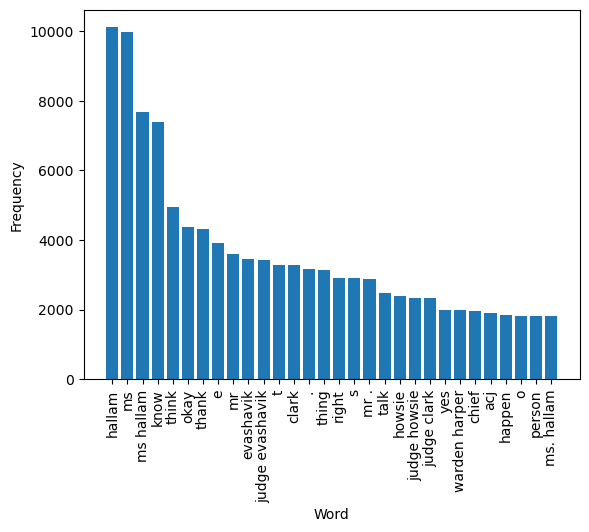

In [111]:
def get_top_words(tf_1d_table, vocab, num_top_words=20):
    return sorted(zip(tf_1d_table, vocab), reverse=True)[:num_top_words]

def print_top_words(tf_1d_table, vocab, num_top_words=20):
    sorted_tuples = get_top_words(tf_1d_table, vocab, num_top_words)

    for _, word in sorted_tuples:
        print(word, end=' ')
    print()

def plot_top_words(tf_1d_table, vocab, num_top_words=20, divide_by_sum=False):
    if divide_by_sum:
        tf_1d_table = tf_1d_table / tf_1d_table.sum()
    sorted_tuples = get_top_words(tf_1d_table, vocab, num_top_words)
    top_counts, top_words = zip(*sorted_tuples)

    plt.bar(range(num_top_words), top_counts)
    plt.xticks(range(num_top_words), top_words, rotation=90)
    plt.xlabel('Word')
    plt.ylabel('Frequency')

plot_top_words(np.array(tf.sum(axis=0)).flatten(), vocab, num_top_words=30)

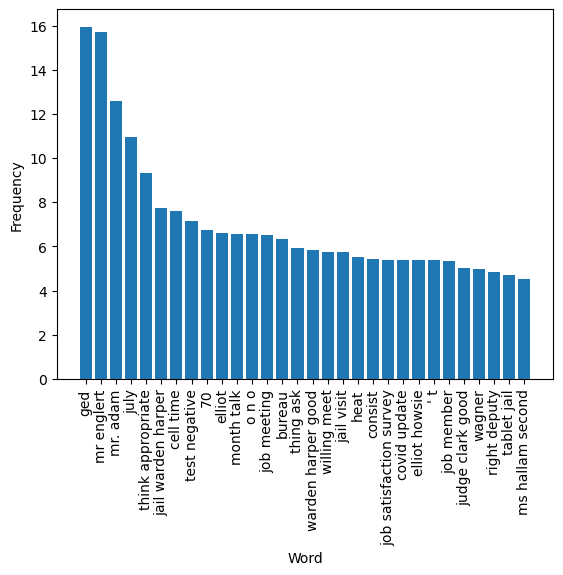

In [112]:
plot_top_words(np.array(tfidf.sum(axis=0)).flatten(), vocab, num_top_words=30)

### Immediate observations are that names are some of the most frequent n-grams (probably since speakers are identified). Hallam is an exceptionally frequent speaker. Also, we see some Covid related terms in TF-IDF table (e.g. test negative and covid update). Something that could be interesting is to see which speakers occur most frequently. This could also be used to filter these people from analysis in later steps.

In [ ]:
names = []

# Identified by looking at documents
titles = ['ms', 'mr', 'judge', 'warden', 'sheriff']

for word in vocab:
    # Getting title name bi-grams
    if any(word.startswith(title) for title in titles) and len(word.split()) == 2:
        names.append(word)
names # Extracting the last names will be the next part of this analysis

['judge beth',
 'judge bigley',
 'judge cashman',
 'judge clark',
 'judge court',
 'judge david',
 'judge donna',
 'judge elliot',
 'judge evashavik',
 'judge howsie',
 'judge joseph',
 'judge judge',
 'judge kelly',
 'judge kim',
 'judge know',
 'judge lazzara',
 'judge manning',
 'judge mcdaniel',
 'judge susan',
 'judge williams',
 'judge woodruff',
 'mr .',
 'mr bacharach',
 'mr englert',
 'mr harris',
 'mr herbinko',
 'mr james',
 'mr o',
 'mr palmer',
 'mr price',
 'mr sakaria',
 'mr stevens',
 'mr thomas',
 'mr williams',
 'mr zak',
 'mr. adam',
 'mr. bacharach',
 'mr. davis',
 'mr. defazio',
 'mr. englert',
 'mr. fitzgerald',
 'mr. garcia',
 'mr. herbinko',
 'mr. kamara',
 'mr. kenstowicz',
 'mr. kiselka',
 'mr. korinski',
 'mr. kraus',
 'mr. nassir',
 "mr. o'connor",
 'mr. perkins',
 'mr. pilarski',
 'mr. sykes',
 'mr. talotta',
 'mrs. damick',
 'mrs. marion',
 'mrs. wagner',
 'ms bonavoglia',
 'ms dalton',
 'ms damick',
 'ms dettore',
 'ms finch',
 'ms givner',
 'ms griffin',